# Crypto Perps Funding: Feature Engineering

This notebook builds features for the crypto perpetuals funding case study.
Features capture the core signal families: funding, basis mean-reversion,
momentum, volatility, and cross-sectional dispersion.

**Learning Objectives**:
- Separate realized funding rates from the premium-index basis
- Compute hours-based lookbacks aligned to 8H funding cadence
- Build cross-symbol dispersion features for regime awareness
- Differentiate major vs alt cost tiers for downstream modeling

**Book Reference**: Chapter 8, Section 8.2 (Price-Derived Features)

**Prerequisites**: [`02_labels`](02_labels.ipynb) must have produced the label parquet
files. Price inputs are reloaded via the canonical crypto loader.

**Key Insight**: Realized funding and the premium-index basis are related but
distinct signals. Both must be observed before they enter a feature row.

In [1]:
"""Crypto Perps Funding: Feature Engineering."""

import warnings
from typing import cast

import numpy as np
import polars as pl

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")


def _numeric(value: object, default: float = 0.0) -> float:
    if value is None:
        return default
    return float(cast(int | float, value))

In [2]:
# Production defaults - Papermill injects overrides for CI

In [3]:
# Configuration
CASE_DIR = get_case_study_dir("crypto_perps_funding")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
HOLDOUT_START = "2024-01-01"
BAR_HOURS = 8
EXPECTED_FINANCIAL_FEATURES = 39

# Multi-horizon lookbacks in 8H bars
# (8h=1, 24h=3, 72h=9, 168h=21, 336h=42, 720h=90)
LOOKBACK_MAP = {
    "8h": 1,
    "24h": 3,
    "72h": 9,
    "168h": 21,  # 1 week
    "336h": 42,  # 2 weeks
    "720h": 90,  # 30 days
}

MOMENTUM_HORIZONS = [1, 3, 9, 21, 42, 90]  # bars (8h each)
VOLATILITY_HORIZONS = [3, 9, 21, 42]  # bars
ZSCORE_LOOKBACK = 42  # 14 days in 8h bars

# Majors vs alts for cost-tier differentiation
MAJORS = {"BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"}

## 1. Load Completed Bars and Realized Funding

Binance labels each kline with its bar-open time. Advancing the row by eight
hours places the close, volume, and premium-index observations on their
availability clock. Official funding settlements already carry their payment
timestamp, so they join without an additional shift.

In [4]:
from data import load_crypto_perps

prices_raw = load_crypto_perps(
    frequency="8h",
    start_date=START_DATE,
    end_date=END_DATE,
).sort(["symbol", "timestamp"])
end_exclusive = pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC") + pl.duration(days=1)
prices = prices_raw.with_columns(
    (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
).filter(pl.col("timestamp") < end_exclusive)
n_assets = prices["symbol"].n_unique()

print(f"Loaded {len(prices):,} rows, {n_assets} assets")
print(f"Period: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

# Schema validation
_required = {"timestamp", "symbol", "open", "high", "low", "close", "volume", "premium_index_close"}
_missing = _required - set(prices.columns)
assert not _missing, f"Loader missing columns: {_missing}"

Loaded 108,298 rows, 19 assets
Period: 2020-01-01 08:00:00+00:00 to 2025-12-31 16:00:00+00:00


## 2. Join the Official Settlement Series

Binance's realized funding rate includes its interest component and exchange
clamp. The premium-index close is retained separately as the observed basis.
Missing settlements are not filled from the premium proxy.

In [5]:
funding = load_funding_rates(
    symbols=prices["symbol"].unique().to_list(),
    start_date=START_DATE,
    end_date=END_DATE,
)

# Sum every realized settlement in the trailing seven calendar days. Binance
# can temporarily shorten one contract's settlement interval to 2 or 4 hours,
# so a 21-row sum on the common 8-hour panel would omit real cash flows.
funding_cashflows = (
    funding.with_columns(
        pl.when(pl.col("funding_rate") > 0)
        .then(pl.col("funding_rate"))
        .otherwise(0.0)
        .alias("_positive_funding")
    )
    .rolling(index_column="timestamp", period="7d", group_by="symbol", closed="right")
    .agg(pl.col("_positive_funding").sum().alias("cum_positive_funding_7d"))
)
features = prices.join(
    funding.select("timestamp", "symbol", "funding_rate"),
    on=["timestamp", "symbol"],
    how="left",
).join(
    funding_cashflows,
    on=["timestamp", "symbol"],
    how="left",
)
funding_coverage = features["funding_rate"].is_not_null().mean()
assert funding_coverage is not None and funding_coverage > 0.99
print(f"Realized funding coverage: {funding_coverage:.2%}")

Realized funding coverage: 99.68%


In [6]:
# Premium change (1 bar = 8h)
features = features.with_columns(
    (pl.col("premium_index_close") - pl.col("premium_index_close").shift(1).over("symbol")).alias(
        "premium_change_1bar"
    ),
    # Log return on perp price (clip(1e-8) guards against div-by-zero)
    (pl.col("close") / pl.col("close").shift(1).over("symbol").clip(lower_bound=1e-8) - 1).alias(
        "price_return_8h"
    ),
)

print(f"Base features computed: {len(features):,} rows")

Base features computed: 108,298 rows


## 3. Carry / Funding Rate Features (Primary Family)

The core signal family. Funding rate z-score, half-life of mean-reversion,
cumulative funding, and level indicators.

In [7]:
def _add_premium_zscores(df: pl.DataFrame) -> pl.DataFrame:
    for name, bars in [("7d", 21), ("14d", 42)]:
        df = df.with_columns(
            pl.col("premium_index_close")
            .rolling_mean(window_size=bars)
            .over("symbol")
            .alias(f"_prem_mean_{name}"),
            pl.col("premium_index_close")
            .rolling_std(window_size=bars)
            .over("symbol")
            .alias(f"_prem_std_{name}"),
        )
        df = df.with_columns(
            (
                (pl.col("premium_index_close") - pl.col(f"_prem_mean_{name}"))
                / pl.col(f"_prem_std_{name}").clip(lower_bound=1e-8)
            )
            .clip(-10, 10)
            .alias(f"premium_zscore_{name}")
        )
        df = df.drop([f"_prem_mean_{name}", f"_prem_std_{name}"])
    return df

In [8]:
def _add_funding_zscore(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        pl.col("funding_rate").rolling_mean(window_size=42).over("symbol").alias("_fr_mean"),
        pl.col("funding_rate").rolling_std(window_size=42).over("symbol").alias("_fr_std"),
    )
    df = df.with_columns(
        ((pl.col("funding_rate") - pl.col("_fr_mean")) / pl.col("_fr_std").clip(lower_bound=1e-8))
        .clip(-10, 10)
        .alias("funding_rate_zscore_14d")
    )
    return df.drop(["_fr_mean", "_fr_std"])

In [9]:
def _add_funding_half_life(df: pl.DataFrame) -> pl.DataFrame:
    fr_lag = pl.col("funding_rate").shift(1).over("symbol")
    df = df.with_columns(
        (
            (pl.col("funding_rate") * fr_lag).rolling_mean(window_size=42).over("symbol")
            - pl.col("funding_rate").rolling_mean(window_size=42).over("symbol")
            * fr_lag.rolling_mean(window_size=42).over("symbol")
        ).alias("_cov_fr"),
        fr_lag.rolling_var(window_size=42, ddof=0).over("symbol").alias("_var_fr_lag"),
    )
    df = df.with_columns(
        (pl.col("_cov_fr") / pl.col("_var_fr_lag").clip(lower_bound=1e-12))
        .clip(-0.999, 0.999)
        .alias("_ar1_coef")
    )
    df = df.with_columns(
        pl.when(pl.col("_ar1_coef").abs() > 0.01)
        .then(-np.log(2) / pl.col("_ar1_coef").abs().log().clip(lower_bound=-10))
        .otherwise(pl.lit(42.0))
        .clip(lower_bound=0.5, upper_bound=100.0)
        .alias("funding_half_life_14d")
    )
    return df.drop(["_cov_fr", "_var_fr_lag", "_ar1_coef"])

In [10]:
def compute_carry_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute carry/funding rate features."""
    df = df.sort(["symbol", "timestamp"])
    df = _add_premium_zscores(df)
    df = _add_funding_zscore(df)
    df = df.with_columns(
        pl.col("premium_index_close").alias("premium_level"),
        pl.col("premium_index_close")
        .rank(method="ordinal")
        .over("timestamp")
        .alias("premium_rank"),
    )
    return _add_funding_half_life(df)

## 4. Mean Reversion Features

Distance from rolling percentiles and quantile position. These measure
how extreme the current premium is relative to its recent distribution.

In [11]:
def _add_premium_quantiles(df: pl.DataFrame) -> pl.DataFrame:
    for name, bars in [("7d", 21), ("14d", 42), ("30d", 90)]:
        df = df.with_columns(
            pl.col("premium_index_close")
            .rolling_min(window_size=bars)
            .over("symbol")
            .alias(f"_min_{name}"),
            pl.col("premium_index_close")
            .rolling_max(window_size=bars)
            .over("symbol")
            .alias(f"_max_{name}"),
        )
        df = df.with_columns(
            (
                (pl.col("premium_index_close") - pl.col(f"_min_{name}"))
                / (pl.col(f"_max_{name}") - pl.col(f"_min_{name}")).clip(lower_bound=1e-8)
            )
            .clip(0, 1)
            .alias(f"premium_quantile_pos_{name}")
        )
        df = df.drop([f"_min_{name}", f"_max_{name}"])
    return df

In [12]:
def compute_mean_reversion_features(df: pl.DataFrame) -> pl.DataFrame:
    """Mean reversion and distance-from-extreme features."""
    df = df.sort(["symbol", "timestamp"])
    for name, bars in [("7d", 21), ("14d", 42)]:
        df = df.with_columns(
            (
                pl.col("premium_index_close")
                - pl.col("premium_index_close").rolling_mean(window_size=bars).over("symbol")
            ).alias(f"premium_dev_mean_{name}")
        )
    df = _add_premium_quantiles(df)
    df = df.with_columns(
        pl.when(pl.col("premium_index_close") > 0)
        .then(1.0)
        .otherwise(0.0)
        .rolling_mean(window_size=21)
        .over("symbol")
        .alias("premium_persistence_7d")
    )
    return df

## 5. Momentum Features

Multi-horizon premium changes and acceleration (momentum of momentum).

In [13]:
def compute_momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """Multi-horizon momentum and acceleration features."""
    df = df.sort(["symbol", "timestamp"])

    # Multi-horizon momentum (raw premium changes)
    for bars in MOMENTUM_HORIZONS:
        label = f"{bars * 8}h"  # Convert bars to hours for naming
        df = df.with_columns(
            (
                pl.col("premium_index_close")
                - pl.col("premium_index_close").shift(bars).over("symbol")
            ).alias(f"premium_change_{label}")
        )

    # Funding-rate change over 24h (3 bars)
    df = df.with_columns(
        (pl.col("funding_rate") - pl.col("funding_rate").shift(3).over("symbol")).alias(
            "funding_rate_change_24h"
        )
    )

    # Acceleration (momentum of momentum)
    df = df.with_columns(
        (pl.col("premium_change_24h") - pl.col("premium_change_72h")).alias("premium_accel_short"),
        (pl.col("premium_change_72h") - pl.col("premium_change_168h")).alias(
            "premium_accel_medium"
        ),
    )

    return df

## 6. Volatility Features

Premium volatility at multiple horizons and vol ratios. These capture
regime information (high vol often coincides with liquidation cascades).

In [14]:
def compute_volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Multi-horizon volatility and vol ratio features."""
    df = df.sort(["symbol", "timestamp"])

    # Rolling volatility of premium changes
    for bars in VOLATILITY_HORIZONS:
        label = f"{bars * 8}h"
        df = df.with_columns(
            pl.col("premium_change_1bar")
            .rolling_std(window_size=bars)
            .over("symbol")
            .alias(f"premium_vol_{label}")
        )

    # Vol ratios: short/long
    df = df.with_columns(
        (pl.col("premium_vol_24h") / pl.col("premium_vol_168h").clip(lower_bound=1e-8))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_short"),
        (pl.col("premium_vol_72h") / pl.col("premium_vol_336h").clip(lower_bound=1e-8))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_medium"),
    )

    # Price return volatility (from perps close)
    df = df.with_columns(
        pl.col("price_return_8h").rolling_std(window_size=21).over("symbol").alias("price_vol_7d"),
        pl.col("price_return_8h").rolling_std(window_size=42).over("symbol").alias("price_vol_14d"),
    )

    return df

## 7. Cross-Sectional Features

How each symbol's premium relates to the market. Cross-symbol funding
dispersion measures whether opportunities are concentrated or broad.

In [15]:
def compute_cross_sectional_features(df: pl.DataFrame) -> pl.DataFrame:
    """Cross-sectional normalization and dispersion features."""
    # Premium vs cross-sectional median
    df = df.with_columns(
        (
            pl.col("premium_index_close") - pl.col("premium_index_close").median().over("timestamp")
        ).alias("premium_vs_median")
    )

    # Cross-sectional z-score
    df = df.with_columns(
        (
            (pl.col("premium_index_close") - pl.col("premium_index_close").mean().over("timestamp"))
            / pl.col("premium_index_close").std().over("timestamp").clip(lower_bound=1e-8)
        )
        .clip(-10, 10)
        .alias("premium_xs_zscore")
    )

    # Cross-symbol funding dispersion (same value for all symbols at each timestamp)
    # High dispersion = opportunities; low dispersion = crowded market
    df = df.with_columns(
        pl.col("funding_rate").std().over("timestamp").alias("xs_funding_dispersion")
    )

    return df

**Data timing note**: Cross-sectional statistics use the completed premium-index bars
available on the common 00:00, 08:00, and 16:00 UTC grid. Realized funding remains a
symbol-level feature because Binance can temporarily shorten an individual contract's
settlement interval.

## 8. Regime and Calendar Features

Premium regime indicator (sustained premium vs discount) and session
indicator for the three daily funding timestamps.

In [16]:
def _add_premium_rsi(df: pl.DataFrame) -> pl.DataFrame:
    gain = (
        pl.when(pl.col("premium_change_1bar") > 0).then(pl.col("premium_change_1bar")).otherwise(0)
    )
    loss = (
        pl.when(pl.col("premium_change_1bar") < 0)
        .then(pl.col("premium_change_1bar").abs())
        .otherwise(0)
    )

    for bars in [3, 9]:  # 24h, 72h
        label = f"{bars * 8}h"
        df = df.with_columns(
            gain.rolling_mean(window_size=bars).over("symbol").alias(f"_avg_gain_{bars}"),
            loss.rolling_mean(window_size=bars).over("symbol").alias(f"_avg_loss_{bars}"),
        )
        df = df.with_columns(
            (
                100
                - (
                    100
                    / (
                        1
                        + pl.col(f"_avg_gain_{bars}")
                        / pl.col(f"_avg_loss_{bars}").clip(lower_bound=1e-8)
                    )
                )
            ).alias(f"premium_rsi_{label}")
        )
        df = df.drop([f"_avg_gain_{bars}", f"_avg_loss_{bars}"])
    return df

In [17]:
def compute_regime_calendar_features(df: pl.DataFrame) -> pl.DataFrame:
    """Regime indicators and calendar features."""
    df = df.sort(["symbol", "timestamp"])
    df = df.with_columns(
        pl.when(pl.col("premium_index_close") > 0)
        .then(1)
        .otherwise(-1)
        .cast(pl.Float64)
        .rolling_mean(window_size=9)
        .over("symbol")
        .alias("premium_regime_72h")
    )
    df = _add_premium_rsi(df)
    df = df.with_columns(
        (pl.col("timestamp").dt.hour() / 8).cast(pl.Int32).alias("funding_session"),
        pl.when(pl.col("symbol").is_in(list(MAJORS))).then(0).otherwise(1).alias("cost_tier_alt"),
    )
    return df

## 9. Apply All Feature Pipelines

In [18]:
features = (
    features.pipe(compute_carry_features)
    .pipe(compute_mean_reversion_features)
    .pipe(compute_momentum_features)
    .pipe(compute_volatility_features)
    .pipe(compute_cross_sectional_features)
    .pipe(compute_regime_calendar_features)
)

print(f"Features computed: {len(features):,} rows, {len(features.columns)} total columns")

Features computed: 108,298 rows, 52 total columns


## 10. Select and Save Feature Matrix

Select feature columns, drop metadata, and save. The output uses
(`timestamp`, `symbol`) as the key columns.

In [19]:
# Columns to exclude from feature matrix
EXCLUDE_COLS = {
    "timestamp",
    "symbol",
    # Raw data columns
    "premium_index_open",
    "premium_index_high",
    "premium_index_low",
    "premium_index_close",
    "open",
    "high",
    "low",
    "close",
    "volume",
    # Intermediate columns
    "premium_change_1bar",
    "price_return_8h",
}

feature_cols = sorted([c for c in features.columns if c not in EXCLUDE_COLS])
output_cols = ["timestamp", "symbol"] + feature_cols

unexpected_feature_keys = {"symbol", "timestamp"} & set(feature_cols)
assert not unexpected_feature_keys, (
    f"Feature matrix leaked key columns: {sorted(unexpected_feature_keys)}"
)

# Drop rows with nulls in feature columns (warm-up period)
feature_output = features.select(output_cols).drop_nulls()

n_features = len(feature_cols)
assert n_features == EXPECTED_FINANCIAL_FEATURES, (
    f"Financial-feature contract changed: expected {EXPECTED_FINANCIAL_FEATURES}, got {n_features}"
)
print("\nFeature Matrix:")
print(f"  Features:  {n_features}")
print(f"  Rows:      {len(feature_output):,}")
print(f"  Assets:    {feature_output['symbol'].n_unique()}")
print(f"  Period:    {feature_output['timestamp'].min()} to {feature_output['timestamp'].max()}")


Feature Matrix:
  Features:  39
  Rows:      100,812
  Assets:    19
  Period:    2020-01-31 08:00:00+00:00 to 2025-12-31 16:00:00+00:00


In [20]:
carry_family = [
    c
    for c in feature_cols
    if c.startswith("premium_zscore_")
    or c.startswith("funding_rate")
    or c
    in {
        "premium_level",
        "premium_rank",
        "cum_positive_funding_7d",
        "funding_half_life_14d",
    }
]
mean_reversion_family = [
    c for c in feature_cols if any(k in c for k in ["dev_mean", "quantile_pos", "persistence"])
]
momentum_family = [
    c for c in feature_cols if c.startswith("premium_change_") or c.startswith("premium_accel_")
]
volatility_family = [
    c
    for c in feature_cols
    if c.startswith("premium_vol_") or c.startswith("price_vol_") or c.startswith("vol_ratio_")
]

In [21]:
cross_sectional_family = [
    c
    for c in feature_cols
    if c in {"premium_vs_median", "premium_xs_zscore", "xs_funding_dispersion"}
]
regime_calendar_family = [
    c
    for c in feature_cols
    if c.startswith("premium_regime_")
    or c.startswith("premium_rsi_")
    or c in {"funding_session", "cost_tier_alt"}
]
families = {
    "Carry/Funding": carry_family,
    "Mean Reversion": mean_reversion_family,
    "Momentum": momentum_family,
    "Volatility": volatility_family,
    "Cross-Sectional": cross_sectional_family,
    "Regime/Calendar": regime_calendar_family,
}

In [22]:
family_memberships = {
    feature: [family for family, columns in families.items() if feature in columns]
    for feature in feature_cols
}
assert all(len(memberships) == 1 for memberships in family_memberships.values()), (
    "Feature-family assignment must be one-to-one: "
    f"{ {k: v for k, v in family_memberships.items() if len(v) != 1} }"
)

print("\nFeature Families:")
accounted = set()
for family, cols in families.items():
    print(f"  {family}: {len(cols)} features")
    accounted.update(cols)

unaccounted = set(feature_cols) - accounted
if unaccounted:
    print(f"  Other: {len(unaccounted)} ({', '.join(sorted(unaccounted)[:5])}...)")


Feature Families:
  Carry/Funding: 9 features
  Mean Reversion: 6 features
  Momentum: 8 features
  Volatility: 8 features
  Cross-Sectional: 3 features
  Regime/Calendar: 5 features


**Interpretation**: The 39-column contract spans six non-overlapping families.
Funding and basis transformations remain separate, while volatility,
cross-sectional, and calendar columns provide conditioning state for downstream
models rather than additional versions of the same level signal.

**Feature count note**: The matrix prioritizes transformations with a clear
information-time definition. Order-book imbalance and liquidation metrics remain
outside the dataset because the current source does not provide their full history.

## 11. Feature Evaluation

We evaluate every engineered feature against the primary forward return
label using:
- **Information Coefficient (IC)**: Cross-sectional Spearman rank correlation
  per timestamp, then averaged across timestamps
- **HAC adjustment**: Newey-West standard errors accounting for autocorrelation
  in the IC time series
- **BH-FDR**: Benjamini-Hochberg false discovery rate correction for multiple
  testing across the complete feature family
- **Pairwise correlation**: Identify redundant feature pairs (|corr| > 0.7)

In [23]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family based on naming pattern."""
    for family, columns in families.items():
        if feature_name in columns:
            return family.lower().replace("/", "_").replace("-", "_").replace(" ", "_")
    raise KeyError(f"Unassigned feature: {feature_name}")

### Load Labels and Join

In [24]:
import plotly.graph_objects as go
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import spearmanr as _spearmanr
from scipy.stats import t as _student_t

_label_df = pl.read_parquet(LABELS_DIR / "fwd_ret_8h.parquet")
_label_cols = [c for c in _label_df.columns if c not in ("timestamp", "symbol")]
assert len(_label_cols) == 1, f"Expected one label column, found {_label_cols}"
_label_col = cast(str, _label_cols[0])

# Admit an evaluation row only when its complete 8-hour label endpoint is
# strictly before holdout. Equality belongs to the sealed holdout.
_holdout_start = pl.lit(HOLDOUT_START).str.to_datetime().dt.replace_time_zone("UTC")
eval_df = feature_output.join(_label_df, on=["timestamp", "symbol"], how="inner").filter(
    pl.col("timestamp") + pl.duration(hours=BAR_HOURS) < _holdout_start
)
assert eval_df.select(
    (pl.col("timestamp").max() + pl.duration(hours=BAR_HOURS) < _holdout_start).alias("sealed")
).item()
print(
    f"Evaluation set: {len(eval_df):,} rows (label endpoints before holdout), "
    f"label column: {_label_col}"
)

Evaluation set: 59,416 rows (label endpoints before holdout), label column: fwd_ret_8h


### Per-Feature IC with HAC Adjustment

In [25]:
ic_results = {}

if eval_df is not None:
    assert _label_col is not None
    _partitions = eval_df.partition_by("timestamp", as_dict=True)

    for feat in feature_cols:
        ic_vals = []
        for _key, group in _partitions.items():
            vals = group.select([feat, _label_col]).drop_nulls()
            if len(vals) >= 10:
                ic, _ = _spearmanr(vals[feat].to_numpy(), vals[_label_col].to_numpy())
                if not np.isnan(ic):
                    ic_vals.append(ic)
        if len(ic_vals) >= 20:
            hac_stats = compute_ic_hac_stats(np.array(ic_vals))
            hac_stats["naive_p_value"] = float(
                2 * _student_t.sf(abs(hac_stats["naive_t_stat"]), df=len(ic_vals) - 1)
            )
            ic_results[feat] = hac_stats

    print(f"IC computed for {len(ic_results)} / {len(feature_cols)} features")
    non_cross_sectional = sorted(set(feature_cols) - set(ic_results))
    print(f"Not cross-sectionally identifiable: {non_cross_sectional}")

IC computed for 37 / 39 features
Not cross-sectionally identifiable: ['funding_session', 'xs_funding_dispersion']


### BH-FDR Multiple Testing Correction

In [26]:
if ic_results:
    _feat_names = list(ic_results.keys())
    _p_values = [ic_results[f]["p_value"] for f in _feat_names]

    fdr_result = benjamini_hochberg_fdr(_p_values, alpha=0.05, return_details=True)

    eval_summary = pl.DataFrame(
        {
            "feature": _feat_names,
            "family": [assign_feature_family(f) for f in _feat_names],
            "ic_mean": [ic_results[f]["mean_ic"] for f in _feat_names],
            "hac_se": [ic_results[f]["hac_se"] for f in _feat_names],
            "hac_tstat": [ic_results[f]["t_stat"] for f in _feat_names],
            "p_value": _p_values,
            "adjusted_p": list(fdr_result["adjusted_p_values"]),
            "significant_fdr05": list(fdr_result["rejected"]),
            "naive_tstat": [ic_results[f]["naive_t_stat"] for f in _feat_names],
            "naive_p_value": [ic_results[f]["naive_p_value"] for f in _feat_names],
        }
    ).sort("ic_mean", descending=True)

    n_significant = int(fdr_result["n_rejected"])
    n_naive_sig = sum(1 for f in _feat_names if ic_results[f]["naive_p_value"] < 0.05)
    inflation = n_naive_sig / max(n_significant, 1)

    print(f"Features tested: {len(_feat_names)}")
    print(f"Naive significant (p < 0.05): {n_naive_sig}")
    print(f"FDR-corrected significant: {n_significant}")
    print(f"Inflation factor: {inflation:.1f}x")

Features tested: 37
Naive significant (p < 0.05): 30
FDR-corrected significant: 30
Inflation factor: 1.0x


### IC Bar Chart (Top 20)

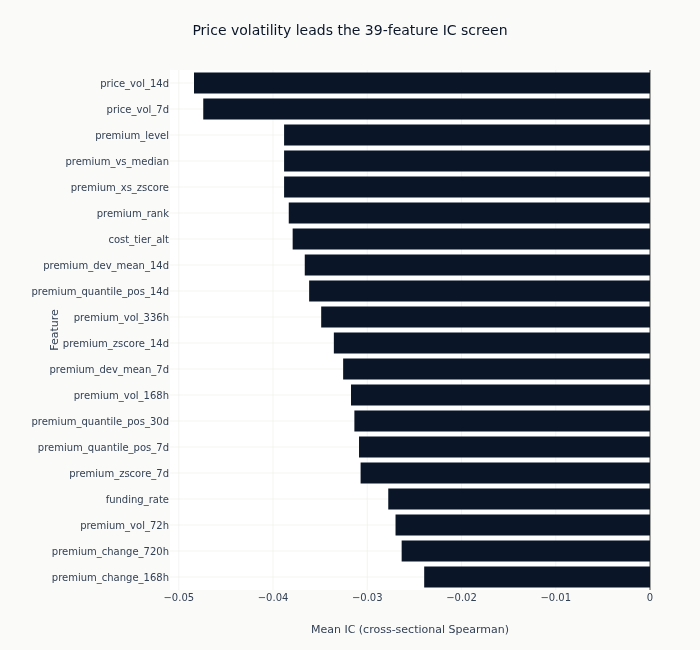

In [27]:
if ic_results:
    top_20 = eval_summary.sort(pl.col("ic_mean").abs(), descending=True).head(20)

    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x=top_20["ic_mean"].to_list(),
            y=top_20["feature"].to_list(),
            orientation="h",
            marker_color=COLORS["blue"],
        )
    )
    fig.update_layout(
        title="Price volatility leads the 39-feature IC screen",
        xaxis_title="Mean IC (cross-sectional Spearman)",
        yaxis_title="Feature",
        yaxis=dict(autorange="reversed"),
        height=650,
        margin=dict(l=170, r=50, t=70, b=60),
    )
    fig.show()

### Pairwise Feature Correlation

In [28]:
high_corr_pairs = []

if eval_df is not None:
    # Sample every 5th timestamp for efficiency
    _sample_ts = eval_df["timestamp"].unique().sort().gather_every(5)
    _corr_data = (
        eval_df.filter(pl.col("timestamp").is_in(_sample_ts))
        .select(feature_cols)
        .to_pandas()
        .corr(method="spearman")
    )

    for i, f1 in enumerate(_corr_data.columns):
        for j, f2 in enumerate(_corr_data.columns):
            if i < j and abs(_corr_data.iloc[i, j]) > 0.7:
                high_corr_pairs.append((f1, f2, float(_corr_data.iloc[i, j])))

    print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 38


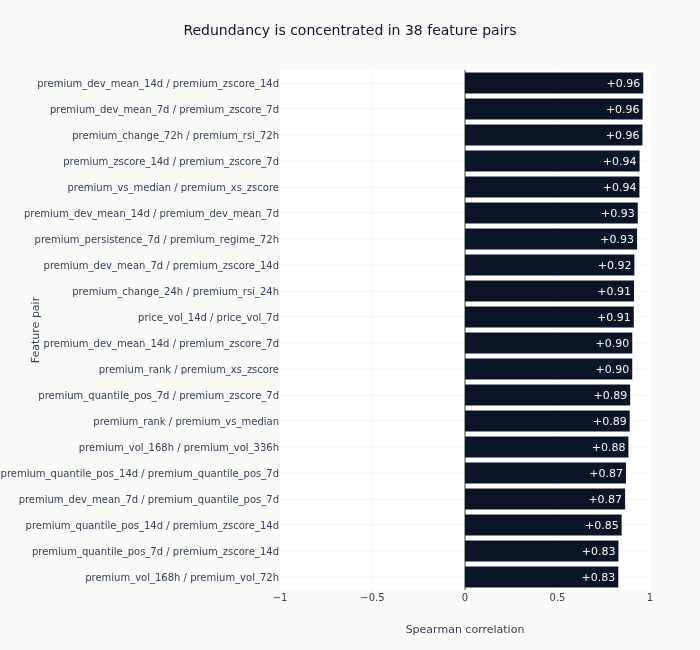

In [29]:
if high_corr_pairs:
    strongest_pairs = sorted(high_corr_pairs, key=lambda row: abs(row[2]), reverse=True)[:20]
    pair_labels = [f"{left} / {right}" for left, right, _ in strongest_pairs]
    pair_values = [correlation for _, _, correlation in strongest_pairs]

    fig = go.Figure(
        go.Bar(
            x=pair_values,
            y=pair_labels,
            orientation="h",
            marker_color=[
                COLORS["blue"] if correlation >= 0 else COLORS["amber"]
                for correlation in pair_values
            ],
            text=[f"{correlation:+.2f}" for correlation in pair_values],
            textposition="inside",
            textfont=dict(color=COLORS["silver"]),
        )
    )
    fig.update_layout(
        title="Redundancy is concentrated in 38 feature pairs",
        xaxis_title="Spearman correlation",
        yaxis_title="Feature pair",
        xaxis=dict(range=[-1, 1]),
        yaxis=dict(autorange="reversed"),
        height=650,
        margin=dict(l=280, r=50, t=70, b=60),
    )
    fig.show()

### HAC vs Naive t-statistics

In [30]:
if ic_results:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=eval_summary["naive_tstat"].to_list(),
            y=eval_summary["hac_tstat"].to_list(),
            mode="markers",
            text=eval_summary["feature"].to_list(),
            marker=dict(
                color=COLORS["blue"],
                size=8,
            ),
            showlegend=False,
        )
    )
    _max_t = (
        max(
            abs(_numeric(eval_summary["naive_tstat"].min())),
            abs(_numeric(eval_summary["naive_tstat"].max())),
            abs(_numeric(eval_summary["hac_tstat"].min())),
            abs(_numeric(eval_summary["hac_tstat"].max())),
        )
        * 1.1
    )

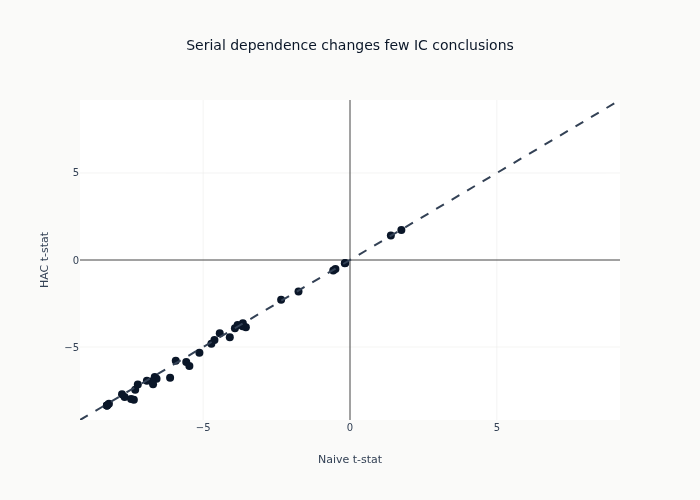

In [31]:
if ic_results:
    fig.add_trace(
        go.Scatter(
            x=[-_max_t, _max_t],
            y=[-_max_t, _max_t],
            mode="lines",
            line=dict(dash="dash", color=COLORS["neutral"]),
            showlegend=False,
        )
    )
    fig.update_layout(
        title="Serial dependence changes few IC conclusions",
        xaxis_title="Naive t-stat",
        yaxis_title="HAC t-stat",
        xaxis=dict(range=[-_max_t, _max_t], zeroline=True),
        yaxis=dict(range=[-_max_t, _max_t], zeroline=True),
        height=500,
    )
    fig.show()

**Interpretation**:
- 30 of 37 cross-sectionally identifiable features survive 5% FDR correction.
  `funding_session` and `xs_funding_dispersion` are common within a timestamp,
  so a cross-sectional IC is not defined for them.
- Price volatility has the largest IC magnitude (`price_vol_14d`: -0.0486).
  The official `funding_rate` remains significant with IC -0.0278, but it is not
  the strongest standalone predictor.
- The matrix contains 38 pairs with absolute Spearman correlation above 0.7.
  Regularized downstream models must absorb this within-family redundancy.

## 12. Save Feature Matrix

In [32]:
# Save features
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
feature_output.write_parquet(FEATURES_DIR / "financial.parquet")
print(f"\nSaved {n_features} features to features/financial.parquet")
print(f"  Shape: {feature_output.shape}")


Saved 39 features to features/financial.parquet
  Shape: (100812, 41)


## Key Takeaways

1. **The 39-feature contract is complete**: 100,812 rows survive the 30-day
   warm-up and missing-settlement filter, with 99.68% realized-funding coverage
   before that filter.

2. **Information timing is explicit**: Bar-open timestamps move to the bar close,
   so every feature row is dated when its inputs are available.

3. **Funding is useful but not dominant**: Its single-feature IC is -0.0278,
   compared with -0.0486 for 14-day price volatility.

4. **Redundancy is material**: 38 feature pairs exceed an absolute correlation
   of 0.7, which motivates regularization rather than manual selection on this
   development-period diagnostic.

**Next**: `04_model_based_features` adds train-fitted volatility and regime features.